In [1]:
import sys

print("Python executable:")
print(sys.executable)

Python executable:
D:\AIML\WEEK4\Audio_Similarity_YAMNet\venv\Scripts\python.exe


In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
print("TensorFlow Hub:", hub.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)


TensorFlow: 2.21.0
TFDS: 4.9.10
TensorFlow Hub: 0.16.1
NumPy: 2.2.6
Pandas: 2.3.3
Scikit-learn: 1.7.2


In [1]:
!pip install transformers torchaudio

  Using cached transformers-5.14.1-py3-none-any.whl.metadata (32 kB)
  Using cached torchaudio-2.11.0-cp310-cp310-win_amd64.whl.metadata (6.9 kB)
  Using cached regex-2026.7.19-cp310-cp310-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.27.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached filelock-3.32.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.5-py3-none-any.whl.metadata (6.5 kB)
Using cached transformers-5.14.1-py3-none-any.whl (11.6 MB)
   ---------------------------------------- 0.0/784.9 kB ? eta -:--:--
   ------------- -------------------------- 262.1/784.9 kB ? eta -:--:--
   --------------------

In [3]:
import tensorflow_datasets as tfds

print("speech_commands" in tfds.list_builders())

True


In [ ]:
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2Model

In [ ]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

In [1]:
import tensorflow_datasets as tfds

data_dir = "../data/tfds"

dataset, info = tfds.load(
    "speech_commands",
    split="train[:1%]",
    with_info=True,
    data_dir=data_dir2
)

print("Dataset loaded successfully!")
print(dataset)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

D:\AIML\WEEK4\Audio_Similarity_YAMNet\venv\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling ..\data\tfds\speech_commands\incomplete.ZWWYYA_0.0.3\speech_commands-validation.tfrecord-[0-9][0-9][…

Generating test examples...: 0 examples [00:00, ? examples/s]

D:\AIML\WEEK4\Audio_Similarity_YAMNet\venv\lib\site-packages\pydub\utils.py:198: RuntimeWarning: Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work
  warn("Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work", RuntimeWarning)


FileNotFoundError: [WinError 2] The system cannot find the file specified

In [2]:
import os

ffmpeg_dir = r"C:\Users\Lenovo\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg.Shared_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-9.0-full_build-shared\bin"

os.environ["PATH"] += os.pathsep + ffmpeg_dir

print("FFmpeg path added.")

FFmpeg path added.


In [3]:
from pydub import AudioSegment

AudioSegment.converter = os.path.join(
    ffmpeg_dir,
    "ffmpeg.exe"
)

AudioSegment.ffprobe = os.path.join(
    ffmpeg_dir,
    "ffprobe.exe"
)

print("FFmpeg:", AudioSegment.converter)
print("FFprobe:", AudioSegment.ffprobe)

FFmpeg: C:\Users\Lenovo\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg.Shared_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-9.0-full_build-shared\bin\ffmpeg.exe
FFprobe: C:\Users\Lenovo\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg.Shared_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-9.0-full_build-shared\bin\ffprobe.exe


In [4]:
import shutil

print("FFmpeg found:", shutil.which("ffmpeg"))
print("FFprobe found:", shutil.which("ffprobe"))

FFmpeg found: C:\Users\Lenovo\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg.Shared_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-9.0-full_build-shared\bin\ffmpeg.EXE
FFprobe found: C:\Users\Lenovo\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg.Shared_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-9.0-full_build-shared\bin\ffprobe.EXE


In [5]:
import subprocess

result = subprocess.run(
    [AudioSegment.ffprobe, "-version"],
    capture_output=True,
    text=True
)

print(result.stdout.splitlines()[0])

ffprobe version 9.0-full_build-www.gyan.dev Copyright (c) 2007-2026 the FFmpeg developers


In [6]:
import tensorflow_datasets as tfds

data_dir = "../data/tfds"

dataset, info = tfds.load(
    "speech_commands",
    split="train[:1%]",
    with_info=True,
    data_dir=data_dir
)

print("Dataset loaded successfully!")
print(dataset)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling ..\data\tfds\speech_commands\incomplete.CEHV1Y_0.0.3\speech_commands-train.tfrecord-[0-9][0-9][0-9][…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling ..\data\tfds\speech_commands\incomplete.CEHV1Y_0.0.3\speech_commands-validation.tfrecord-[0-9][0-9][…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling ..\data\tfds\speech_commands\incomplete.CEHV1Y_0.0.3\speech_commands-test.tfrecord-[0-9][0-9][0-9][0…

Dataset speech_commands downloaded and prepared to ..\data\tfds\speech_commands\0.0.3. Subsequent calls will reuse this data.
Dataset loaded successfully!
<_PrefetchDataset element_spec={'audio': TensorSpec(shape=(None,), dtype=tf.int16, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


In [7]:
print(dataset)

<_PrefetchDataset element_spec={'audio': TensorSpec(shape=(None,), dtype=tf.int16, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


In [8]:
print("Dataset information:")
print(info)

Dataset information:
tfds.core.DatasetInfo(
    name='speech_commands',
    full_name='speech_commands/0.0.3',
    description="""
    An audio dataset of spoken words designed to help train and evaluate keyword
    spotting systems. Its primary goal is to provide a way to build and test small
    models that detect when a single word is spoken, from a set of ten target words,
    with as few false positives as possible from background noise or unrelated
    speech. Note that in the train and validation set, the label "unknown" is much
    more prevalent than the labels of the target words or background noise. One
    difference from the release version is the handling of silent segments. While in
    the test set the silence segments are regular 1 second files, in the training
    they are provided as long segments under "background_noise" folder. Here we
    split these background noise into 1 second clips, and also keep one of the files
    for the validation set.
    """,
    homep

In [9]:
class_names = info.features["label"].names

print("Number of classes:", len(class_names))
print("\nClasses:")
for i, name in enumerate(class_names):
    print(i, "->", name)

Number of classes: 12

Classes:
0 -> down
1 -> go
2 -> left
3 -> no
4 -> off
5 -> on
6 -> right
7 -> stop
8 -> up
9 -> yes
10 -> _silence_
11 -> _unknown_


In [10]:
print("Number of examples in selected split:")
print(info.splits["train"].num_examples)

Number of examples in selected split:
106497


In [11]:
for example in dataset.take(1):
    audio = example["audio"]
    label = example["label"]

    print("Audio shape:", audio.shape)
    print("Audio datatype:", audio.dtype)
    print("Label:", label.numpy())
    print("Label name:", class_names[label.numpy()])

Audio shape: (16000,)
Audio datatype: <dtype: 'int16'>
Label: 4
Label name: off


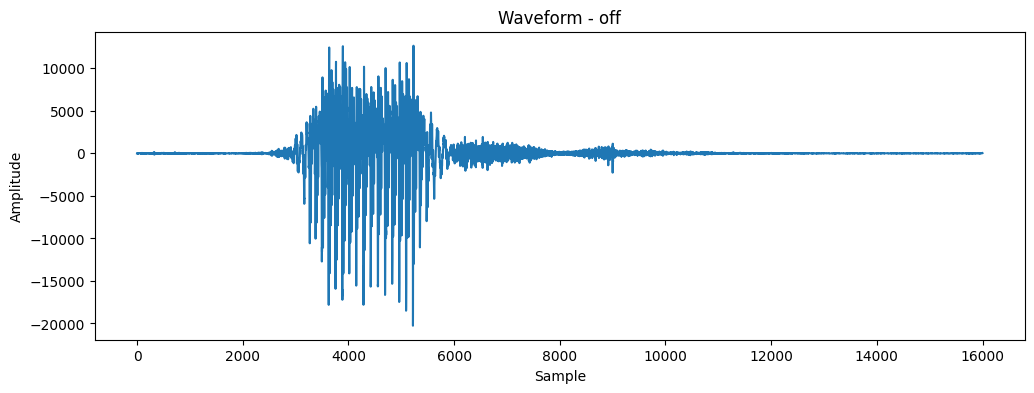

In [12]:
import matplotlib.pyplot as plt
import numpy as np

for example in dataset.take(1):
    audio = example["audio"].numpy()
    label = example["label"].numpy()

plt.figure(figsize=(12, 4))

plt.plot(audio)

plt.title(f"Waveform - {class_names[label]}")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [13]:
print("Minimum amplitude:", audio.min())
print("Maximum amplitude:", audio.max())
print("Mean amplitude:", audio.mean())

Minimum amplitude: -20265
Maximum amplitude: 12647
Mean amplitude: 1.9534375


In [15]:
print(info.features["audio"])

Audio(shape=(None,), dtype=int16)


In [16]:
SAMPLE_RATE = 16000

print("Sampling rate:", SAMPLE_RATE, "Hz")

Sampling rate: 16000 Hz


In [17]:
from IPython.display import Audio, display

for example in dataset.take(1):
    audio = example["audio"].numpy()
    label = example["label"].numpy()

    display(Audio(audio, rate=SAMPLE_RATE))

    print("Label:", class_names[label])

Label: off


In [18]:
selected_classes = [
    "yes",
    "no",
    "up",
    "down",
    "left",
    "right"
]

clips_per_class = 5

print("Selected classes:", selected_classes)
print("Clips per class:", clips_per_class)
print("Expected total clips:", len(selected_classes) * clips_per_class)

Selected classes: ['yes', 'no', 'up', 'down', 'left', 'right']
Clips per class: 5
Expected total clips: 30


In [19]:
selected_clips = []

class_counts = {
    class_name: 0
    for class_name in selected_classes
}

for example in dataset:
    label_id = int(example["label"].numpy())
    label_name = class_names[label_id]

    if label_name in selected_classes:
        if class_counts[label_name] < clips_per_class:

            selected_clips.append({
                "audio": example["audio"].numpy(),
                "label_id": label_id,
                "label": label_name
            })

            class_counts[label_name] += 1

    if all(
        count == clips_per_class
        for count in class_counts.values()
    ):
        break

print("Collected clips:", len(selected_clips))
print("\nClass distribution:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Collected clips: 30

Class distribution:
yes: 5
no: 5
up: 5
down: 5
left: 5
right: 5


In [20]:
import pandas as pd

clip_summary = pd.DataFrame({
    "Clip Index": range(len(selected_clips)),
    "Label": [clip["label"] for clip in selected_clips],
    "Label ID": [clip["label_id"] for clip in selected_clips],
    "Number of Samples": [len(clip["audio"]) for clip in selected_clips]
})

clip_summary

,Clip Index,Label,Label ID,Number of Samples
0,0,left,2,12456
1,1,right,6,16000
2,2,right,6,16000
3,3,right,6,16000
4,4,right,6,16000
5,5,yes,9,16000
6,6,left,2,16000
7,7,yes,9,16000
8,8,left,2,16000
9,9,right,6,16000


In [22]:
clip_summary["Duration (seconds)"] = (
    clip_summary["Number of Samples"] / SAMPLE_RATE
)

clip_summary

,Clip Index,Label,Label ID,Number of Samples,Duration (seconds)
0,0,left,2,12456,0.778500
1,1,right,6,16000,1.000000
2,2,right,6,16000,1.000000
3,3,right,6,16000,1.000000
4,4,right,6,16000,1.000000
5,5,yes,9,16000,1.000000
6,6,left,2,16000,1.000000
7,7,yes,9,16000,1.000000
8,8,left,2,16000,1.000000
9,9,right,6,16000,1.000000


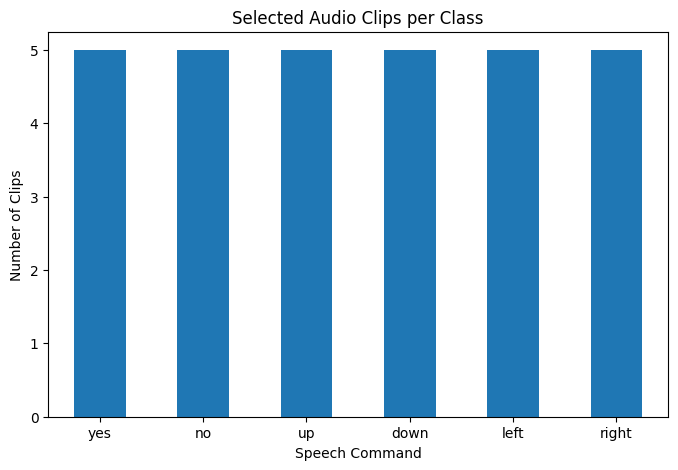

In [23]:
plt.figure(figsize=(8, 5))

clip_summary["Label"].value_counts().reindex(selected_classes).plot(
    kind="bar"
)

plt.title("Selected Audio Clips per Class")
plt.xlabel("Speech Command")
plt.ylabel("Number of Clips")
plt.xticks(rotation=0)

plt.show()

In [24]:
from IPython.display import Audio, display

for class_name in selected_classes:

    clip = next(
        clip for clip in selected_clips
        if clip["label"] == class_name
    )

    print(f"Class: {class_name}")

    display(
        Audio(
            clip["audio"],
            rate=SAMPLE_RATE
        )
    )

Class: yes


Class: no


Class: up


Class: down


Class: left


Class: right


In [25]:
def preprocess_audio(audio):
    """
    Convert int16 audio samples to float32
    and normalize them to approximately [-1, 1].
    """
    
    audio = audio.astype(np.float32)

    audio = audio / 32768.0

    return audio

In [26]:
test_audio = selected_clips[0]["audio"]

processed_audio = preprocess_audio(test_audio)

print("Original dtype:", test_audio.dtype)
print("Processed dtype:", processed_audio.dtype)

print("\nOriginal range:")
print(test_audio.min(), "to", test_audio.max())

print("\nProcessed range:")
print(processed_audio.min(), "to", processed_audio.max())

Original dtype: int16
Processed dtype: float32

Original range:
-9641 to 8274

Processed range:
-0.29421997 to 0.25250244


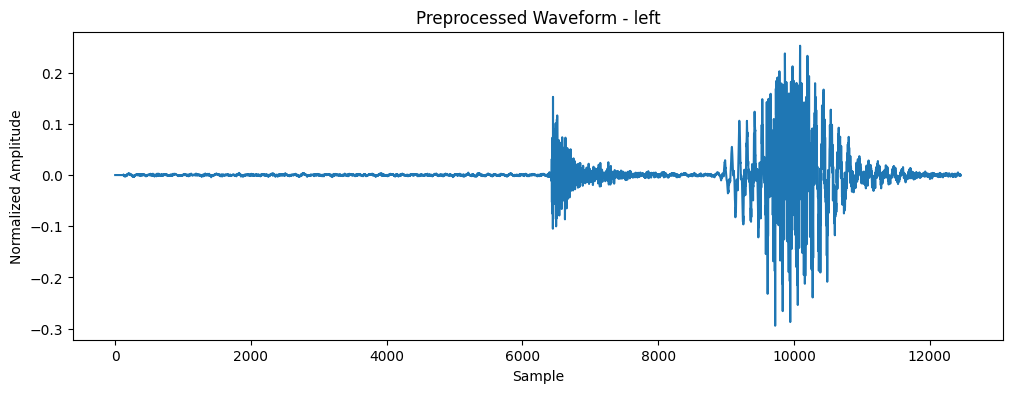

In [27]:
plt.figure(figsize=(12, 4))

plt.plot(processed_audio)

plt.title(
    f"Preprocessed Waveform - {selected_clips[0]['label']}"
)

plt.xlabel("Sample")
plt.ylabel("Normalized Amplitude")

plt.show()

In [28]:
import tensorflow_hub as hub

In [29]:
yamnet_model = hub.load(
    "https://tfhub.dev/google/yamnet/1"
)

print("YAMNet loaded successfully!")

YAMNet loaded successfully!


In [ ]:
processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

wav2vec_model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

wav2vec_model = wav2vec_model.to(device)
wav2vec_model.eval()

print("Wav2Vec2 loaded successfully!")
print("Device:", device)

In [30]:
print(yamnet_model)

<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject object at 0x000001BC01FEFB80>


In [31]:
sample_clip = selected_clips[0]

sample_audio = preprocess_audio(
    sample_clip["audio"]
)

print("Class:", sample_clip["label"])
print("Audio shape:", sample_audio.shape)
print("Audio dtype:", sample_audio.dtype)

Class: left
Audio shape: (12456,)
Audio dtype: float32


In [34]:
sample_tensor = tf.convert_to_tensor(
    sample_audio,
    dtype=tf.float32
)

scores, embeddings, spectrogram = yamnet_model(
    sample_tensor
)

print("Scores shape:", scores.shape)
print("Embeddings shape:", embeddings.shape)
print("Spectrogram shape:", spectrogram.shape)

Scores shape: (1, 521)
Embeddings shape: (1, 1024)
Spectrogram shape: (96, 64)


In [33]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [35]:
print("Number of YAMNet frames:", embeddings.shape[0])
print("Features per frame:", embeddings.shape[1])

Number of YAMNet frames: 1
Features per frame: 1024


In [36]:
sample_embedding = tf.reduce_mean(
    embeddings,
    axis=0
)

sample_embedding = sample_embedding.numpy()

print("Original YAMNet embedding shape:", embeddings.shape)
print("Final clip embedding shape:", sample_embedding.shape)

Original YAMNet embedding shape: (1, 1024)
Final clip embedding shape: (1024,)


In [37]:
def extract_yamnet_embedding(audio):
    """
    Convert an audio waveform into one 1024-dimensional
    YAMNet embedding.
    """

    # Step 1: Normalize audio
    audio = preprocess_audio(audio)

    # Step 2: Convert NumPy array to TensorFlow tensor
    audio_tensor = tf.convert_to_tensor(
        audio,
        dtype=tf.float32
    )

    # Step 3: Run YAMNet
    scores, frame_embeddings, spectrogram = yamnet_model(
        audio_tensor
    )

    # Step 4: Average frame-level embeddings
    clip_embedding = tf.reduce_mean(
        frame_embeddings,
        axis=0
    )

    # Step 5: Convert TensorFlow tensor to NumPy
    return clip_embedding.numpy()

In [38]:
test_embedding = extract_yamnet_embedding(
    selected_clips[0]["audio"]
)

print("Embedding shape:", test_embedding.shape)
print("Embedding dtype:", test_embedding.dtype)

print("\nFirst 10 embedding values:")
print(test_embedding[:10])

Embedding shape: (1024,)
Embedding dtype: float32

First 10 embedding values:
[0.06168811 0.         0.         0.         0.         0.
 0.02899637 0.00412751 0.04983683 0.00236782]


In [39]:
all_embeddings = []

for i, clip in enumerate(selected_clips):

    embedding = extract_yamnet_embedding(
        clip["audio"]
    )

    all_embeddings.append(embedding)

    print(
        f"Processed {i + 1}/{len(selected_clips)} "
        f"- {clip['label']}"
    )

Processed 1/30 - left
Processed 2/30 - right
Processed 3/30 - right
Processed 4/30 - right
Processed 5/30 - right
Processed 6/30 - yes
Processed 7/30 - left
Processed 8/30 - yes
Processed 9/30 - left
Processed 10/30 - right
Processed 11/30 - down
Processed 12/30 - left
Processed 13/30 - no
Processed 14/30 - down
Processed 15/30 - down
Processed 16/30 - no
Processed 17/30 - down
Processed 18/30 - no
Processed 19/30 - yes
Processed 20/30 - yes
Processed 21/30 - yes
Processed 22/30 - up
Processed 23/30 - down
Processed 24/30 - left
Processed 25/30 - no
Processed 26/30 - no
Processed 27/30 - up
Processed 28/30 - up
Processed 29/30 - up
Processed 30/30 - up


In [40]:
all_embeddings = np.array(all_embeddings)

print("Embedding matrix shape:")
print(all_embeddings.shape)

Embedding matrix shape:
(30, 1024)


In [41]:
embedding_labels = [
    clip["label"]
    for clip in selected_clips
]

print(embedding_labels)

['left', 'right', 'right', 'right', 'right', 'yes', 'left', 'yes', 'left', 'right', 'down', 'left', 'no', 'down', 'down', 'no', 'down', 'no', 'yes', 'yes', 'yes', 'up', 'down', 'left', 'no', 'no', 'up', 'up', 'up', 'up']


In [42]:
from sklearn.preprocessing import normalize

normalized_embeddings = normalize(
    all_embeddings,
    norm="l2"
)

print("Normalized embedding shape:")
print(normalized_embeddings.shape)

Normalized embedding shape:
(30, 1024)


In [43]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    normalized_embeddings
)

print("Similarity matrix shape:")
print(similarity_matrix.shape)

Similarity matrix shape:
(30, 30)


In [44]:
print("Minimum similarity:",
      similarity_matrix.min())

print("Maximum similarity:",
      similarity_matrix.max())

print("Mean similarity:",
      similarity_matrix.mean())

Minimum similarity: 0.16166997
Maximum similarity: 1.0000002
Mean similarity: 0.64290106


In [45]:
print("Diagonal values:")
print(np.diag(similarity_matrix))

Diagonal values:
[0.9999999  1.0000002  1.0000001  1.         1.         0.9999999
 1.0000002  1.         1.         0.9999999  1.         1.
 0.9999999  1.         1.         0.99999994 1.0000002  1.0000001
 1.0000001  1.0000002  0.9999999  1.         1.0000002  1.
 1.         1.         1.0000001  1.0000002  1.         1.        ]


In [46]:
from sklearn.metrics import pairwise_distances

distance_matrix = pairwise_distances(
    normalized_embeddings,
    metric="euclidean"
)

print("Distance matrix shape:")
print(distance_matrix.shape)

Distance matrix shape:
(30, 30)


In [47]:
print("Minimum distance:",
      distance_matrix.min())

print("Maximum distance:",
      distance_matrix.max())

print("Mean distance:",
      distance_matrix.mean())

Minimum distance: 0.0
Maximum distance: 1.2948592
Mean distance: 0.81128377


In [48]:
print("Diagonal values:")
print(np.diag(distance_matrix))

Diagonal values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [49]:
clip_names = []

class_counter = {}

for clip in selected_clips:
    label = clip["label"]

    if label not in class_counter:
        class_counter[label] = 0

    class_counter[label] += 1

    clip_names.append(
        f"{label}_{class_counter[label]}"
    )

print(clip_names)

['left_1', 'right_1', 'right_2', 'right_3', 'right_4', 'yes_1', 'left_2', 'yes_2', 'left_3', 'right_5', 'down_1', 'left_4', 'no_1', 'down_2', 'down_3', 'no_2', 'down_4', 'no_3', 'yes_3', 'yes_4', 'yes_5', 'up_1', 'down_5', 'left_5', 'no_4', 'no_5', 'up_2', 'up_3', 'up_4', 'up_5']


In [50]:
!pip install seaborn

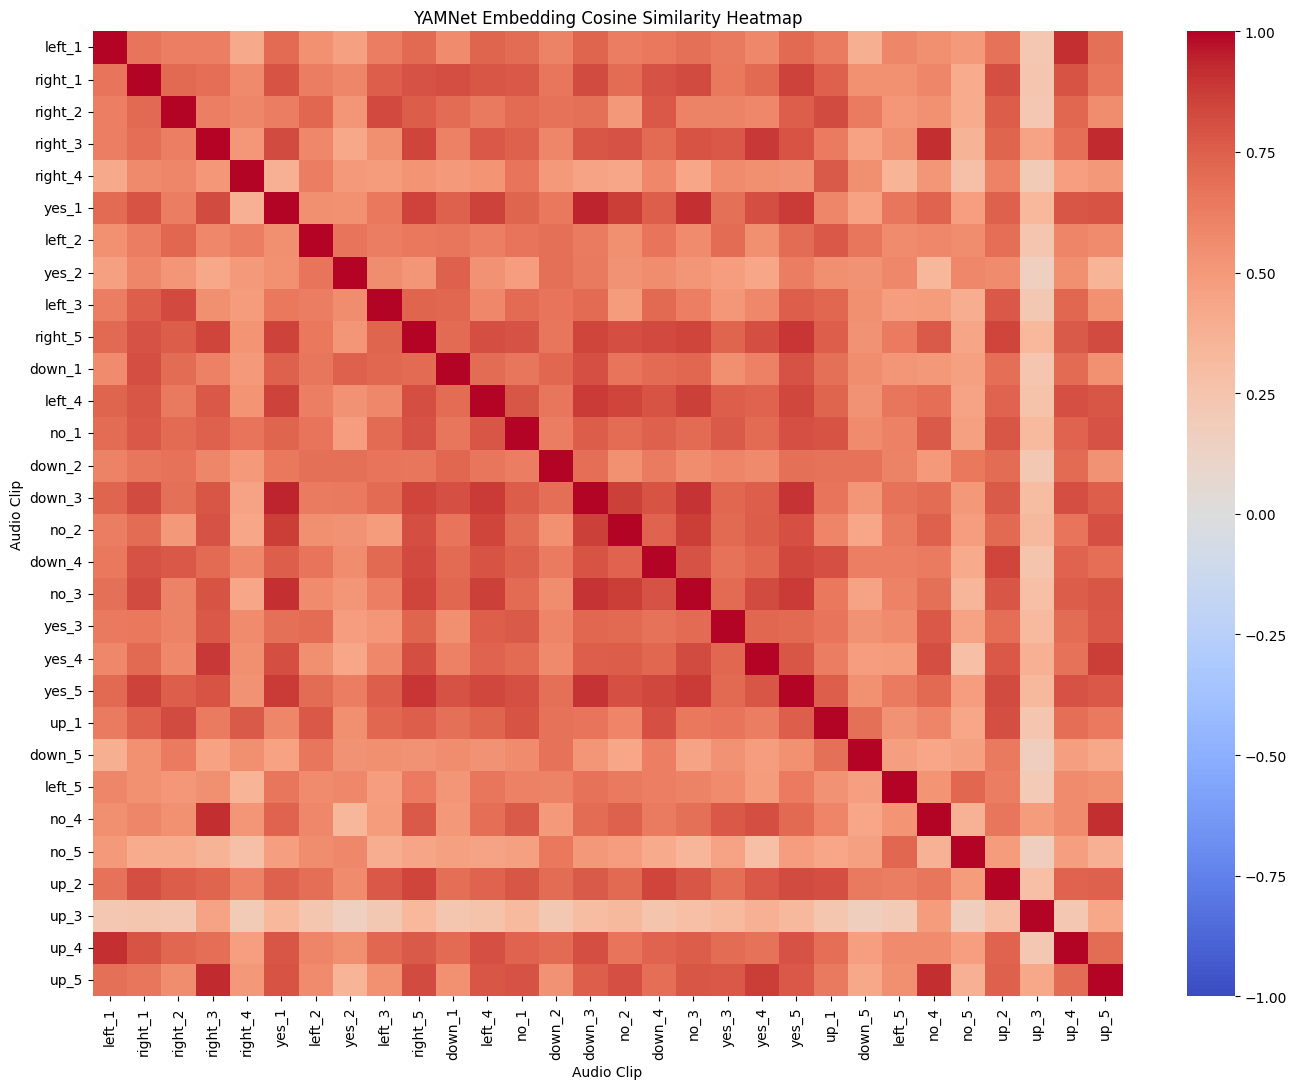

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 11))

sns.heatmap(
    similarity_matrix,
    xticklabels=clip_names,
    yticklabels=clip_names,
    annot=False,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("YAMNet Embedding Cosine Similarity Heatmap")
plt.xlabel("Audio Clip")
plt.ylabel("Audio Clip")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

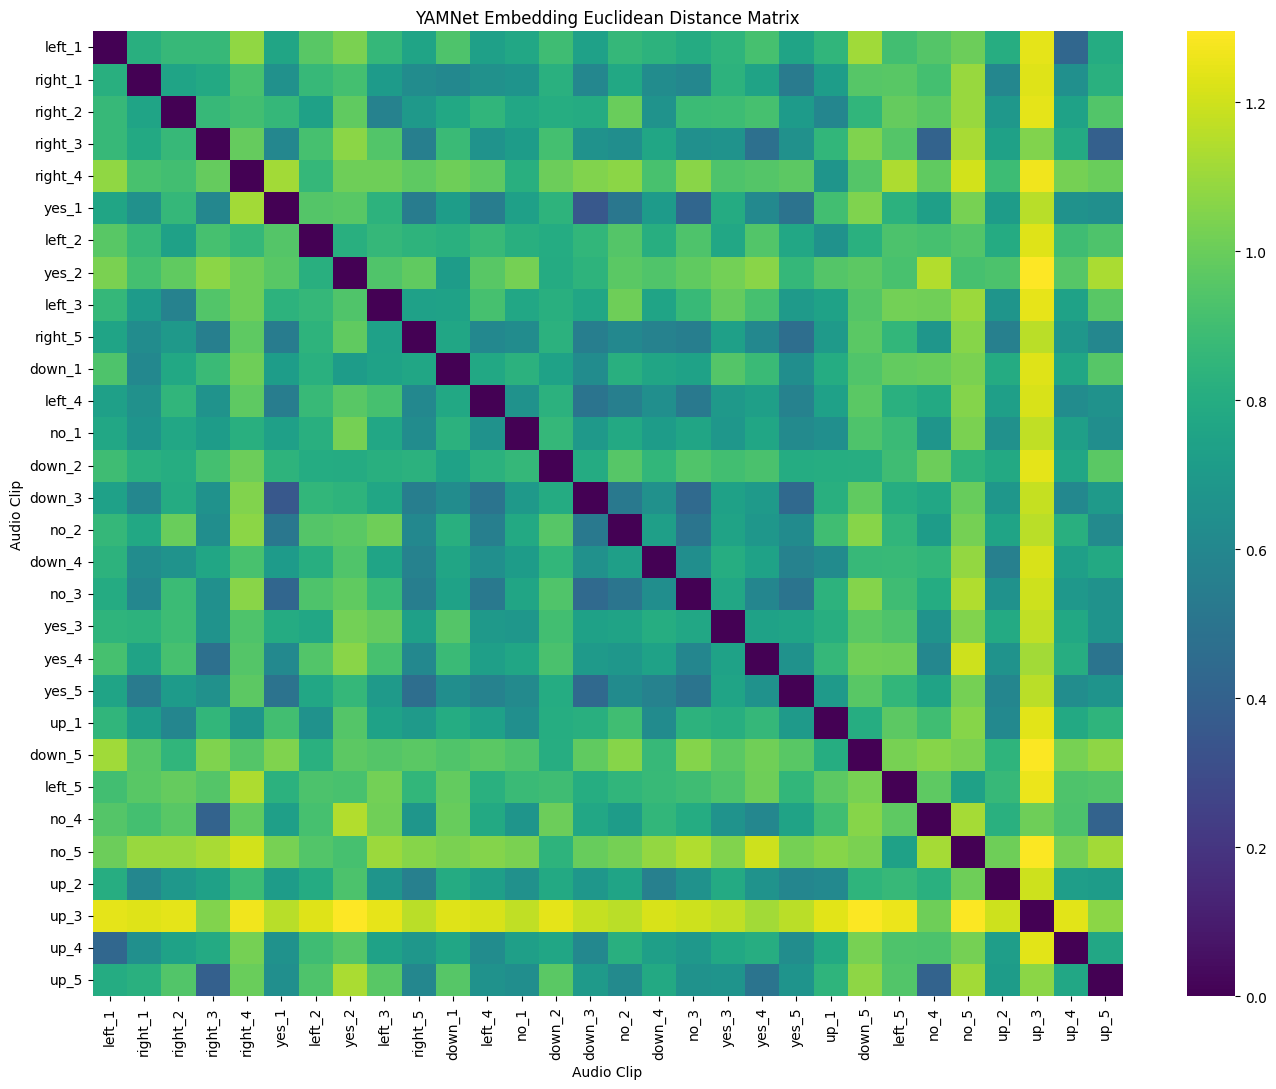

In [52]:
plt.figure(figsize=(14, 11))

sns.heatmap(
    distance_matrix,
    xticklabels=clip_names,
    yticklabels=clip_names,
    annot=False,
    cmap="viridis"
)

plt.title("YAMNet Embedding Euclidean Distance Matrix")
plt.xlabel("Audio Clip")
plt.ylabel("Audio Clip")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [53]:
labels_array = np.array(embedding_labels)

same_class_mask = (
    labels_array[:, None] == labels_array[None, :]
)

different_class_mask = ~same_class_mask

np.fill_diagonal(same_class_mask, False)
np.fill_diagonal(different_class_mask, False)

print("Same-class comparisons:",
      same_class_mask.sum())

print("Different-class comparisons:",
      different_class_mask.sum())

Same-class comparisons: 120
Different-class comparisons: 750


In [54]:
same_class_similarity = similarity_matrix[
    same_class_mask
]

different_class_similarity = similarity_matrix[
    different_class_mask
]

print(
    "Average same-class similarity:",
    same_class_similarity.mean()
)

print(
    "Average different-class similarity:",
    different_class_similarity.mean()
)

Average same-class similarity: 0.62938726
Average different-class similarity: 0.6307793


In [55]:
same_class_distance = distance_matrix[
    same_class_mask
]

different_class_distance = distance_matrix[
    different_class_mask
]

print(
    "Average same-class distance:",
    same_class_distance.mean()
)

print(
    "Average different-class distance:",
    different_class_distance.mean()
)

Average same-class distance: 0.8439404
Average different-class distance: 0.8385101


In [56]:
similarity_no_diag = similarity_matrix.copy()

np.fill_diagonal(
    similarity_no_diag,
    -np.inf
)

best_index = np.unravel_index(
    np.argmax(similarity_no_diag),
    similarity_no_diag.shape
)

i, j = best_index

print("Most similar pair:")
print(clip_names[i])
print(clip_names[j])

print(
    "Similarity:",
    similarity_matrix[i, j]
)

Most similar pair:
yes_1
down_3
Similarity: 0.938408


In [57]:
least_index = np.unravel_index(
    np.argmin(similarity_no_diag),
    similarity_no_diag.shape
)

i, j = least_index

print("Least similar pair:")
print(clip_names[i])
print(clip_names[j])

print(
    "Similarity:",
    similarity_matrix[i, j]
)

Least similar pair:
left_1
left_1
Similarity: 0.9999999


In [58]:
results_summary = pd.DataFrame({
    "Metric": [
        "Number of audio clips",
        "Embedding dimension",
        "Similarity matrix size",
        "Distance matrix size",
        "Average same-class similarity",
        "Average different-class similarity",
        "Average same-class distance",
        "Average different-class distance"
    ],
    
    "Value": [
        len(selected_clips),
        all_embeddings.shape[1],
        str(similarity_matrix.shape),
        str(distance_matrix.shape),
        round(same_class_similarity.mean(), 4),
        round(different_class_similarity.mean(), 4),
        round(same_class_distance.mean(), 4),
        round(different_class_distance.mean(), 4)
    ]
})

results_summary

,Metric,Value
0,Number of audio clips,30
1,Embedding dimension,1024
2,Similarity matrix size,"(30, 30)"
3,Distance matrix size,"(30, 30)"
4,Average same-class similarity,0.6294
5,Average different-class similarity,0.6308
6,Average same-class distance,0.8439
7,Average different-class distance,0.8385


## 10. Observations

In this experiment, 30 audio clips from the Speech Commands dataset were processed using the pretrained YAMNet model. Each audio clip was converted into a 1024-dimensional embedding. These embeddings were then used to calculate pairwise cosine similarity and Euclidean distance.

The resulting similarity and distance matrices were both of size 30 × 30, since every selected audio clip was compared with every other clip.

The average similarity between clips belonging to the same class was 0.6294, while the average similarity between clips belonging to different classes was 0.6308. The difference between these values was very small, indicating that the selected classes were not strongly separated according to cosine similarity in the YAMNet embedding space.

Similarly, the average Euclidean distance for same-class clips was 0.8439, compared with 0.8385 for different-class clips. Ideally, same-class clips would have lower distances than different-class clips. However, the observed difference was small and followed the opposite direction.

These results indicate that YAMNet did not produce strong class-specific separation for the selected Speech Commands audio clips in this experiment. This is reasonable because YAMNet is a general-purpose pretrained audio event model and was not specifically trained to distinguish the individual Speech Commands used in this experiment.

The similarity heatmap and distance matrix provide a visual representation of these relationships. The diagonal of the similarity matrix contains values close to 1 because every audio clip is identical to itself, while the diagonal of the distance matrix contains values close to 0 because the distance between a clip and itself is zero.

Overall, the experiment demonstrates how pretrained audio embeddings can be extracted from raw audio and used to quantitatively measure relationships between different audio clips without training a new neural network from scratch.
